In [3]:
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

plt.rcParams['font.sans-serif'] = 'Times New Roman'
AM = []

plot_dat = np.genfromtxt('Band/generateHz.e')
plot_dat2 = np.genfromtxt('Band/plot_dis_moire_0406.dat')
Hsize = np.size(plot_dat2[0,:])-1
Hsize2 = np.size(plot_dat[:,0])
print(Hsize,Hsize2)
Mass = 0
for i in range(Hsize):
    if plot_dat[i,5] == 1:
        Mass = Mass+plot_dat[i,6]
    else:
        Mass = Mass-plot_dat[i,6]
Avemass = 2*Mass/Hsize*1000
AM.append(Avemass)
for i in range(Hsize):
    if i == Hsize/2:
        #plt.plot(plot_dat[:,0],plot_dat[:,i],'-r')
        V_H = max(plot_dat2[:,i])
    elif i == Hsize/2+1:
        #plt.plot(plot_dat[:,0],plot_dat[:,i],'-r')
        C_M = min(plot_dat2[:,i])
    elif i < Hsize/2+10 and i > Hsize/2-10:
        temp = 0
gap = (C_M-V_H)*1000

print("Actual Gap = ",gap)
print("Average Mass = ",Avemass)

6050 6050
Actual Gap =  11.929230000000013
Average Mass =  5.080802967210598


原子能量计算程序


请输入dat文件路径 (或按Enter使用默认值'your_data.dat'):  
请输入cellInfo文件的基础路径 (或按Enter使用默认值'tGBN_EleventhTest'):  



使用dat文件: tGBN_EleventhTest/energies2.dat
使用基础路径: tGBN_EleventhTest
--------------------------------------------------------------------------------
正在解析dat文件...
找到 15 个角度的FullRelaxed数据
角度列表: [0.0, 0.085, 0.1, 0.2, 0.3, 0.396, 0.5, 0.558, 0.769, 0.915, 1.381, 1.53, 2.06, 2.558, 3.071]

正在计算每个原子的能量...
在 tGBN_EleventhTest 中找到的文件夹:
  - .ipynb_checkpoints
  - Ang0.0
  - Ang0.085
  - Ang0.1
  - Ang0.2
  - Ang0.3
  - Ang0.396
  - Ang0.5
  - Ang0.558
  - Ang0.769
  - Ang0.915
  - Ang1.381
  - Ang1.530
  - Ang2.060
  - Ang2.558
  - Ang3.0705
  - Ang3.071
  - BandConfirm
  - BandInput
  - Build
  - LAMMPSInput
  - OnsiteTest
  - Test_OffDiagonal
  - 1.1
  - 1.5
  - 2.3
  - 2.7
使用默认BN平衡晶格常数: 2.504000 Å

开始处理 15 个角度的数据...
在 tGBN_EleventhTest 中找到的文件夹:
  - .ipynb_checkpoints
  - Ang0.0
  - Ang0.085
  - Ang0.1
  - Ang0.2
  - Ang0.3
  - Ang0.396
  - Ang0.5
  - Ang0.558
  - Ang0.769
  - Ang0.915
  - Ang1.381
  - Ang1.530
  - Ang2.060
  - Ang2.558
  - Ang3.0705
  - Ang3.071
  - BandConfirm
  - BandInpu

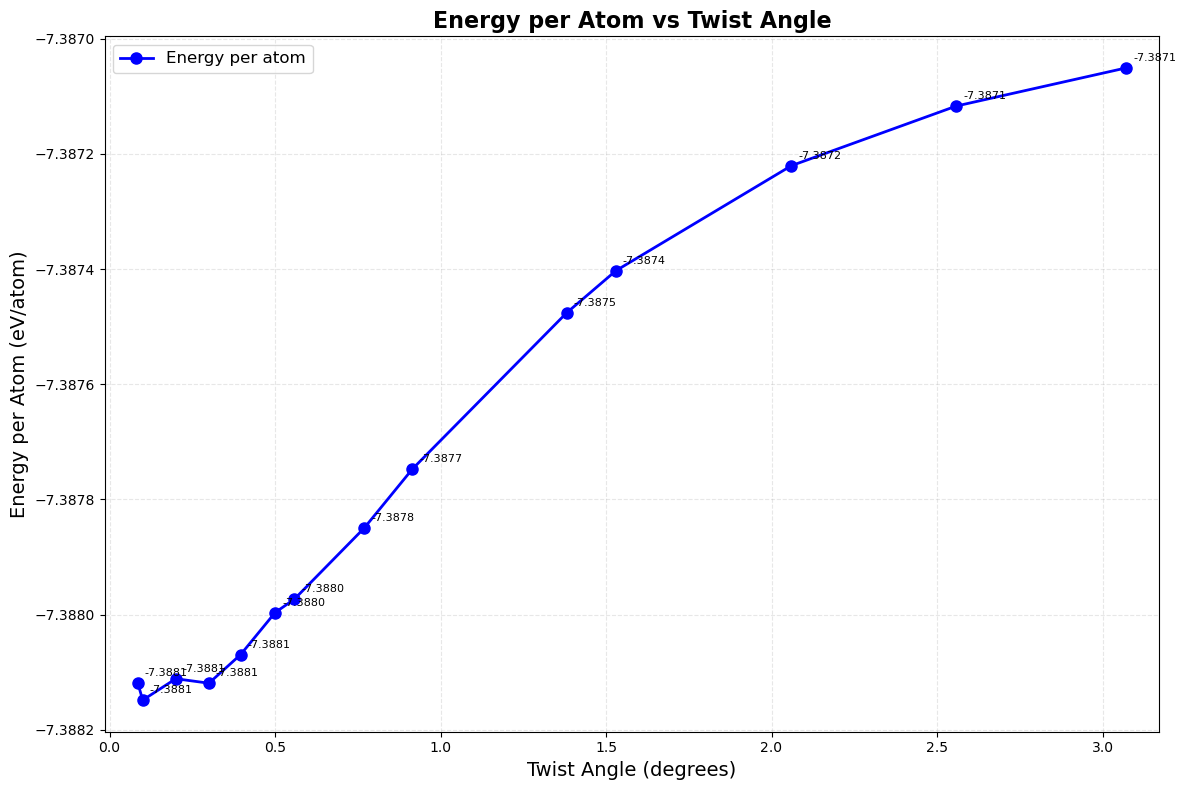

对比图已保存为:
  energy_comparison.png
  energy_comparison.pdf


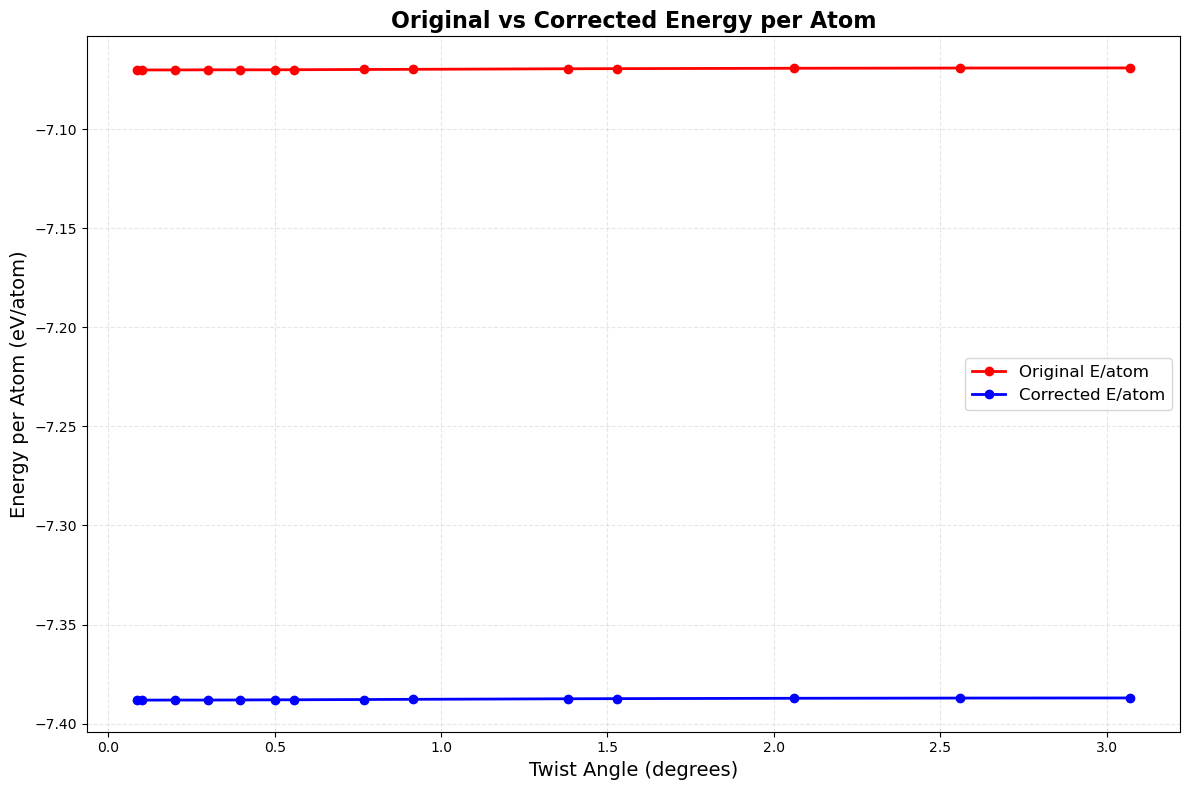


计算完成！
使用的a0 (BN平衡晶格常数): 2.504000 Å
使用的修正因子 κ: 0.045
成功处理的角度数量: 14 / 15
结果文件: energy_per_atom_results.csv


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

def parse_dat_file(dat_path):
    """解析dat文件，提取角度和弛豫后的总能量"""
    data = {}
    with open(dat_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
                
            angle = float(parts[0])
            relax_type = parts[1]
            relaxed_energy = float(parts[-1])  # 最后一列是弛豫后总能量
            
            # 只保留FullRelaxed的数据
            if relax_type == 'FullRelaxed':
                if angle not in data:
                    data[angle] = {}
                data[angle]['relaxed_energy'] = relaxed_energy
                data[angle]['relax_type'] = relax_type
    
    return data

def get_angle_folder_name(angle):
    """根据角度值构造文件夹名
    
    根据提供的示例，角度文件夹的命名格式是：
    Ang0.085, Ang0.0, Ang0.1 等
    """
    # 将浮点数转换为字符串，保留足够的精度
    # 对于整数角度（如0.0），我们可能需要特殊处理
    if abs(angle - round(angle)) < 1e-6:
        # 如果是整数角度
        folder_name = f"Ang{int(angle)}"
    else:
        # 对于小数角度，尝试多种可能的格式
        # 先尝试保留3位小数
        folder_name = f"Ang{angle:.3f}"
        # 如果文件夹不存在，尝试其他格式
        if not os.path.exists(folder_name):
            # 尝试去掉末尾的0
            folder_name = f"Ang{angle}".rstrip('0').rstrip('.')
    
    return folder_name

def parse_cellinfo_file(cellinfo_path):
    """解析cellInfo文件，提取BN晶格常数和原子数"""
    results = {}
    
    if not os.path.exists(cellinfo_path):
        print(f"警告: 文件不存在 {cellinfo_path}")
        return None
    
    try:
        with open(cellinfo_path, 'r') as f:
            content = f.read()
            
            # 提取BN晶格常数
            bn_lattice_match = re.search(r'Final BN lattice parameter:\s+([\d.]+)', content)
            if bn_lattice_match:
                results['bn_lattice'] = float(bn_lattice_match.group(1))
            else:
                print(f"警告: 在 {cellinfo_path} 中未找到BN晶格常数")
                return None
            
            # 提取石墨烯原子数
            graphene_atoms_match = re.search(r'Atoms for graphene:\s+(\d+)', content)
            if graphene_atoms_match:
                results['graphene_atoms'] = int(graphene_atoms_match.group(1))
            else:
                print(f"警告: 在 {cellinfo_path} 中未找到石墨烯原子数")
                return None
            
            # 提取BN原子数
            bn_atoms_match = re.search(r'Atoms for BN:\s+(\d+)', content)
            if bn_atoms_match:
                results['bn_atoms'] = int(bn_atoms_match.group(1))
            else:
                print(f"警告: 在 {cellinfo_path} 中未找到BN原子数")
                return None
            
            # 可选：提取角度用于验证
            angle_match = re.search(r'Final angle:\s+([\d.]+)', content)
            if angle_match:
                results['file_angle'] = float(angle_match.group(1))
            
            return results
    except Exception as e:
        print(f"解析 {cellinfo_path} 时出错: {e}")
        return None

def find_cellinfo_path(base_path, angle):
    """查找cellInfo文件的正确路径"""
    # 尝试几种可能的路径格式
    possible_paths = []
    
    # 格式1: base_path/Ang{angle}/cellInfo
    folder_name = get_angle_folder_name(angle)
    possible_paths.append(os.path.join(base_path, folder_name, 'cellInfo'))
    
    # 格式2: base_path/Ang{angle:.3f}/cellInfo
    possible_paths.append(os.path.join(base_path, f"Ang{angle:.3f}", 'cellInfo'))
    
    # 格式3: base_path/Ang{angle}/cellInfo (不带小数)
    possible_paths.append(os.path.join(base_path, f"Ang{int(angle)}", 'cellInfo'))
    
    # 格式4: base_path/angle_{angle}/cellInfo
    possible_paths.append(os.path.join(base_path, f"angle_{angle}", 'cellInfo'))
    
    # 格式5: base_path/{angle}/cellInfo
    possible_paths.append(os.path.join(base_path, str(angle), 'cellInfo'))
    
    # 尝试所有可能的路径
    for path in possible_paths:
        if os.path.exists(path):
            return path
    
    # 如果找不到，列出base_path下的所有文件夹来帮助调试
    if os.path.exists(base_path):
        print(f"在 {base_path} 中找到的文件夹:")
        for item in os.listdir(base_path):
            if os.path.isdir(os.path.join(base_path, item)):
                print(f"  - {item}")
    
    return None

def calculate_energy_per_atom(data, base_path='tGBN_EleventhTest'):
    """计算每个原子的能量并应用修正公式"""
    results = []
    
    # 首先获取0度时的BN晶格常数作为a0_h-BN
    a0 = None
    angle_0_path = find_cellinfo_path(base_path, 0.0)
    if angle_0_path and os.path.exists(angle_0_path):
        cellinfo_0 = parse_cellinfo_file(angle_0_path)
        if cellinfo_0:
            a0 = cellinfo_0['bn_lattice']
            print(f"使用0度时的BN晶格常数作为a0: {a0:.6f} Å")
    else:
        # 如果没有0度数据，使用常见值2.504 Å
        a0 = 2.504
        print(f"使用默认BN平衡晶格常数: {a0:.6f} Å")
    
    # 如果没有a0，使用平均值
    if a0 is None:
        a0 = 2.504
        print(f"使用文献中常见BN平衡晶格常数: {a0:.6f} Å")
    
    kappa = 0.045  # 修正因子
    
    print(f"\n开始处理 {len(data)} 个角度的数据...")
    print("="*80)
    
    for angle, angle_data in sorted(data.items()):
        # 查找cellInfo文件路径
        cellinfo_path = find_cellinfo_path(base_path, angle)
        
        if not cellinfo_path or not os.path.exists(cellinfo_path):
            print(f"角度 {angle}: 找不到cellInfo文件")
            print(f"  尝试的路径: {cellinfo_path}")
            continue
        
        # 解析cellInfo文件
        cellinfo = parse_cellinfo_file(cellinfo_path)
        if not cellinfo:
            print(f"角度 {angle}: 无法解析cellInfo文件 {cellinfo_path}")
            continue
        
        # 验证角度（可选）
        if 'file_angle' in cellinfo:
            file_angle = cellinfo['file_angle']
            if abs(file_angle - angle) > 0.001:
                print(f"注意: 文件中的角度({file_angle:.6f})与dat文件中的角度({angle:.6f})不一致")
        
        # 计算总原子数和每个原子的能量
        total_atoms = cellinfo['graphene_atoms'] + cellinfo['bn_atoms']
        e_atom = angle_data['relaxed_energy'] / total_atoms
        
        # 应用修正公式: \tilde{E} = E_atom * [1 + κ * (a0 / a_BN)]
        a_bn = cellinfo['bn_lattice']
        e_tilde = e_atom * (1 + kappa * (a0 / a_bn))
        
        # 存储结果
        results.append({
            'angle': angle,
            'total_energy': angle_data['relaxed_energy'],
            'total_atoms': total_atoms,
            'graphene_atoms': cellinfo['graphene_atoms'],
            'bn_atoms': cellinfo['bn_atoms'],
            'a_bn': a_bn,
            'e_atom': e_atom,
            'e_tilde': e_tilde,
            'cellinfo_path': cellinfo_path
        })
        
        print(f"角度 {angle:.6f}:")
        print(f"  cellInfo文件: {cellinfo_path}")
        print(f"  总能量: {angle_data['relaxed_energy']:.2f} eV")
        print(f"  总原子数: {total_atoms} (石墨烯: {cellinfo['graphene_atoms']}, BN: {cellinfo['bn_atoms']})")
        print(f"  BN晶格常数: {a_bn:.6f} Å")
        print(f"  每个原子能量 (原始): {e_atom:.6f} eV/atom")
        print(f"  每个原子能量 (修正): {e_tilde:.6f} eV/atom")
        print(f"  修正因子: 1 + {kappa:.3f} * ({a0:.6f} / {a_bn:.6f}) = {1 + kappa * (a0 / a_bn):.6f}")
        print("-"*60)
    
    return results, a0

def plot_results(results):
    """绘制结果图"""
    if not results:
        print("没有可绘制的数据")
        return
    
    angles = [r['angle'] for r in results]
    e_tilde = [r['e_tilde'] for r in results]
    
    plt.figure(figsize=(12, 8))
    
    # 绘制主图
    plt.plot(angles, e_tilde, 'bo-', linewidth=2, markersize=8, label='Energy per atom')
    
    # 添加数据点标签
    for i, (x, y) in enumerate(zip(angles, e_tilde)):
        plt.annotate(f'{y:.4f}', xy=(x, y), xytext=(5, 5), 
                    textcoords='offset points', fontsize=8)
    
    plt.xlabel('Twist Angle (degrees)', fontsize=14)
    plt.ylabel('Energy per Atom (eV/atom)', fontsize=14)
    plt.title('Energy per Atom vs Twist Angle', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # 设置坐标轴范围
    plt.xlim(min(angles) - 0.1, max(angles) + 0.1)
    
    # 添加图例
    plt.legend(fontsize=12)
    
    plt.tight_layout()
    
    # 保存图片
    png_filename = f'energy_per_atom_vs_angle.png'
    pdf_filename = f'energy_per_atom_vs_angle.pdf'
    
    plt.savefig(png_filename, dpi=300)
    plt.savefig(pdf_filename)
    
    print(f"\n图片已保存为:")
    print(f"  {png_filename}")
    print(f"  {pdf_filename}")
    
    plt.show()
    
    # 额外绘制一个带原始和修正能量的对比图
    if len(results) > 0:
        plt.figure(figsize=(12, 8))
        
        angles = [r['angle'] for r in results]
        e_atom = [r['e_atom'] for r in results]
        e_tilde = [r['e_tilde'] for r in results]
        
        plt.plot(angles, e_atom, 'ro-', linewidth=2, markersize=6, label='Original E/atom')
        plt.plot(angles, e_tilde, 'bo-', linewidth=2, markersize=6, label='Corrected E/atom')
        
        plt.xlabel('Twist Angle (degrees)', fontsize=14)
        plt.ylabel('Energy per Atom (eV/atom)', fontsize=14)
        plt.title('Original vs Corrected Energy per Atom', fontsize=16, fontweight='bold')
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.legend(fontsize=12)
        
        plt.tight_layout()
        
        comp_png = f'energy_comparison.png'
        comp_pdf = f'energy_comparison.pdf'
        
        plt.savefig(comp_png, dpi=300)
        plt.savefig(comp_pdf)
        
        print(f"对比图已保存为:")
        print(f"  {comp_png}")
        print(f"  {comp_pdf}")
        
        plt.show()

def save_results_to_file(results, a0, filename='energy_per_atom_results.csv'):
    """将结果保存到CSV文件"""
    import datetime
    filename = f'energy_per_atom_results.csv'
    
    with open(filename, 'w') as f:
        # 写入标题
        f.write("Angle(deg),Total_Energy(eV),Total_Atoms,Graphene_Atoms,BN_Atoms,"
                "a_BN(Angstrom),E_atom(eV/atom),E_tilde(eV/atom),CellInfo_Path\n")
        
        # 写入数据
        for r in results:
            f.write(f"{r['angle']:.6f},{r['total_energy']:.6f},{r['total_atoms']},"
                    f"{r['graphene_atoms']},{r['bn_atoms']},{r['a_bn']:.6f},"
                    f"{r['e_atom']:.6f},{r['e_tilde']:.6f},{r['cellinfo_path']}\n")
    
    print(f"\n结果已保存到: {filename}")
    return filename

def print_summary_table(results):
    """打印汇总表格"""
    if not results:
        return
    
    print("\n" + "="*100)
    print("汇总表格:")
    print("="*100)
    print(f"{'角度(度)':<12} {'总能量(eV)':<15} {'总原子数':<10} {'E/atom(原始)':<15} {'E/atom(修正)':<15} {'BN晶格常数(Å)':<15}")
    print("-"*100)
    
    for r in results:
        print(f"{r['angle']:<12.6f} {r['total_energy']:<15.2f} {r['total_atoms']:<10} "
              f"{r['e_atom']:<15.6f} {r['e_tilde']:<15.6f} {r['a_bn']:<15.6f}")
    
    print("="*100)

def main():
    import datetime
    
    print("="*80)
    print("原子能量计算程序")
    print("="*80)
    
    # 文件路径设置
    dat_file_path = input("请输入dat文件路径 (或按Enter使用默认值'your_data.dat'): ").strip()
    if not dat_file_path:
        dat_file_path = 'tGBN_EleventhTest/energies2.dat'
    
    base_path = input("请输入cellInfo文件的基础路径 (或按Enter使用默认值'tGBN_EleventhTest'): ").strip()
    if not base_path:
        base_path = 'tGBN_EleventhTest'
    
    # 检查dat文件是否存在
    if not os.path.exists(dat_file_path):
        print(f"错误: dat文件不存在: {dat_file_path}")
        print("请将dat文件放在正确的位置或输入正确的路径")
        return
    
    # 检查基础路径是否存在
    if not os.path.exists(base_path):
        print(f"警告: 基础路径不存在: {base_path}")
        print("可能cellInfo文件位于其他位置，程序将继续尝试查找...")
    
    print(f"\n使用dat文件: {dat_file_path}")
    print(f"使用基础路径: {base_path}")
    print("-"*80)
    
    # 解析dat文件
    print("正在解析dat文件...")
    data = parse_dat_file(dat_file_path)
    print(f"找到 {len(data)} 个角度的FullRelaxed数据")
    
    # 显示找到的角度
    angles_found = sorted(data.keys())
    print(f"角度列表: {angles_found}")
    
    # 计算每个原子的能量
    print("\n正在计算每个原子的能量...")
    results, a0 = calculate_energy_per_atom(data, base_path)
    
    if not results:
        print("错误: 无法计算任何角度的能量")
        print("请检查:")
        print("1. cellInfo文件是否存在于正确的路径")
        print("2. 路径命名是否与角度匹配")
        print("3. cellInfo文件的格式是否正确")
        return
    
    # 打印汇总表格
    print_summary_table(results)
    
    # 保存结果到文件
    csv_file = save_results_to_file(results, a0)
    
    # 绘制图形
    print("\n正在绘制图形...")
    plot_results(results)
    
    # 打印汇总信息
    print("\n" + "="*80)
    print("计算完成！")
    print("="*80)
    #print(f"处理的日期和时间: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"使用的a0 (BN平衡晶格常数): {a0:.6f} Å")
    print(f"使用的修正因子 κ: {0.045}")
    print(f"成功处理的角度数量: {len(results)} / {len(data)}")
    print(f"结果文件: {csv_file}")
    print("="*80)

if __name__ == "__main__":
    main()

In [5]:
import numpy as np

def read_energy_data(file_path):
    """读取dat文件，提取角度和四种弛豫方式的总能量"""
    # 初始化空列表
    angles = []
    energies_fixbn = []
    energies_fullrelaxed = []
    energies_rigid = []
    energies_substrate = []
    
    try:
        with open(file_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                
                # 提取数据
                angle = float(parts[0])
                relax_type = parts[1]
                if relax_type == 'Rigid':
                    relaxed_energy = float(parts[2])  # 最后一列是弛豫后总能量
                else:
                    relaxed_energy = float(parts[-1])  # 最后一列是弛豫后总能量
                
                # 根据弛豫方式分类存储
                if relax_type == 'FixBN':
                    energies_fixbn.append(relaxed_energy)
                elif relax_type == 'FullRelaxed':
                    energies_fullrelaxed.append(relaxed_energy)
                elif relax_type == 'Rigid':
                    energies_rigid.append(relaxed_energy)
                elif relax_type == 'Substrate':
                    energies_substrate.append(relaxed_energy)
                
                # 每个角度只添加一次到角度列表
                if relax_type == 'FixBN':  # 因为每个角度都是从FixBN开始
                    angles.append(angle)
        
        # 转换为numpy数组
        angles_array = np.array(angles)
        energies_fixbn_array = np.array(energies_fixbn)
        energies_fullrelaxed_array = np.array(energies_fullrelaxed)
        energies_rigid_array = np.array(energies_rigid)
        energies_substrate_array = np.array(energies_substrate)
        
        return angles_array, energies_fixbn_array, energies_fullrelaxed_array, energies_rigid_array, energies_substrate_array
    
    except FileNotFoundError:
        print(f"错误: 找不到文件 {file_path}")
        return None

# 使用示例
if __name__ == "__main__":
    # 文件路径
    file_path = "tGBN_EleventhTest/energies2.dat"
    
    # 读取数据
    result = read_energy_data(file_path)
    
    if result:
        angles, e_fixbn, e_fullrelaxed, e_rigid, e_substrate = result
        
        print(f"角度数组: {angles}")
        print(f"FixBN能量数组: {e_fixbn}")
        print(f"FullRelaxed能量数组: {e_fullrelaxed}")
        print(f"Rigid能量数组: {e_rigid}")
        print(f"Substrate能量数组: {e_substrate}")
        
        # 打印每个数组的形状
        print(f"\n数组形状:")
        print(f"角度: {angles.shape}")
        print(f"FixBN能量: {e_fixbn.shape}")
        print(f"FullRelaxed能量: {e_fullrelaxed.shape}")
        print(f"Rigid能量: {e_rigid.shape}")
        print(f"Substrate能量: {e_substrate.shape}")



角度数组: [0.085 0.    0.1   0.2   0.396 0.3   0.558 0.5   0.769 0.915 1.381 1.53
 2.06  2.558 3.071]
FixBN能量数组: [ -82989.5141031  -83993.126526   -84756.0173865  -80995.8755617
  -74506.3248885  -79680.3441691  -65416.1424828  -68215.6401311
  -54727.8080903  -47560.0316843  -92489.7532424  -80741.2452617
  -69501.1597447  -85052.3726251 -185175.47549  ]
FullRelaxed能量数组: [ -83004.1389829  -84008.0463721  -84771.2416726  -81010.0176047
  -74518.8201917  -79694.2610578  -65426.2589933  -68226.4337869
  -54735.3577973  -47565.9749563  -92498.2217293  -80747.9489754
  -69505.4784814  -85056.6908617 -185183.579317 ]
Rigid能量数组: [ -83004.1389829  -84008.0463721  -84771.2416726  -81010.0176047
  -74518.8201917  -79694.2610578  -65426.2589933  -68226.4337869
  -54735.3577973  -47565.9749563  -92498.2217293  -80747.9489754
  -69505.4784814  -85056.6908617 -185183.579317 ]
Substrate能量数组: [-121767.925147  -123242.69      -124369.15      -118845.6
 -109327.598101  -116924.542596   -95983.8897823 -1000

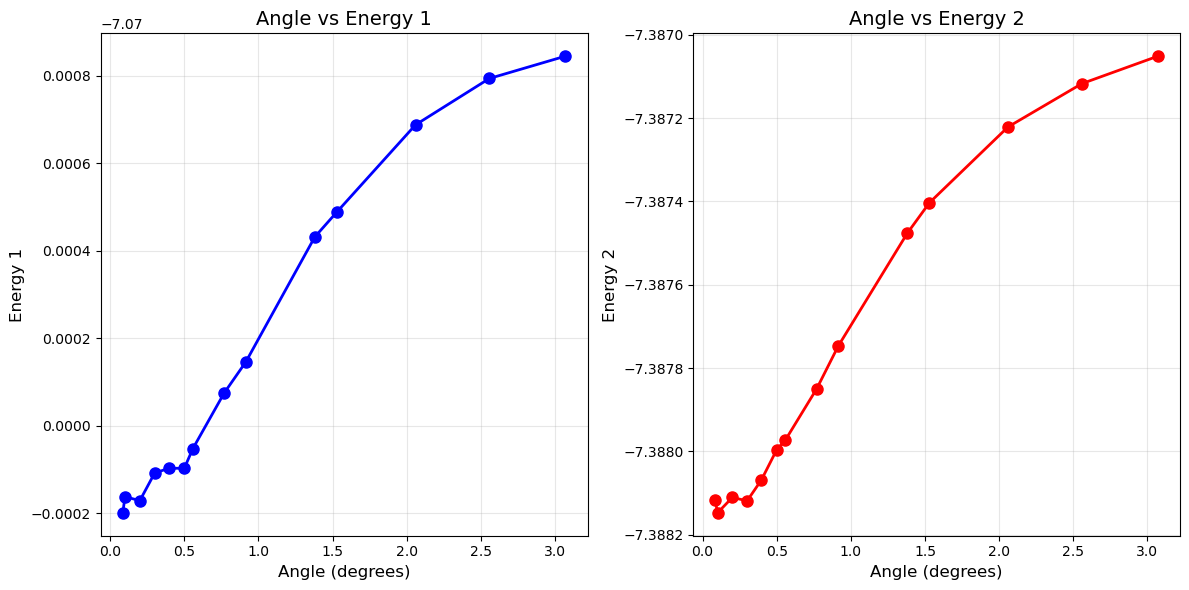

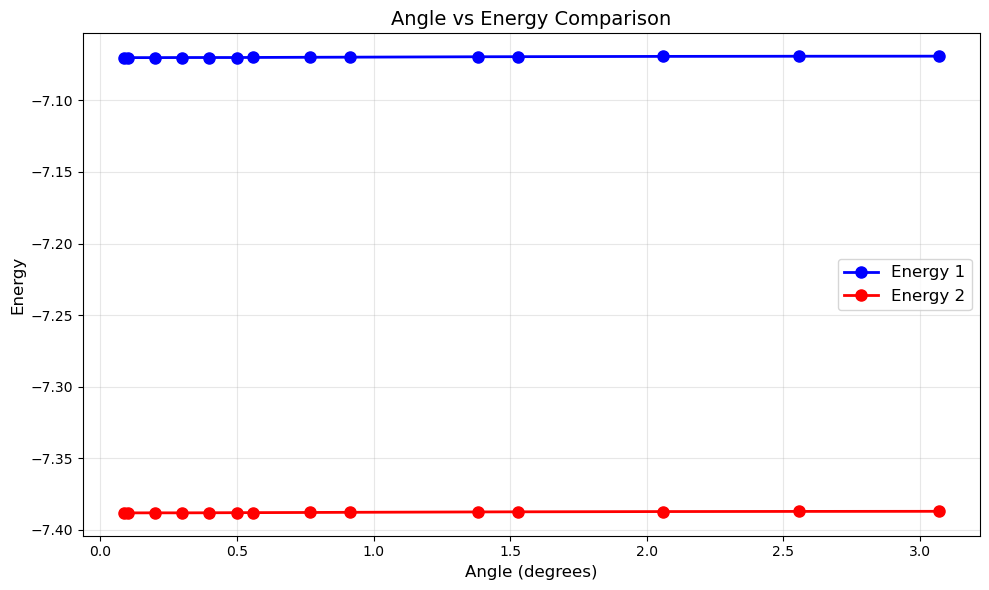

数据摘要:
角度范围: 0.085 - 3.071 度
Energy 1 范围: -7.070199 - -7.069155
Energy 2 范围: -7.388148 - -7.387051
Energy 1 平均值: -7.069815
Energy 2 平均值: -7.387743


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 您的数据
data = [
    [0.085000, -83004.14, 11740, -7.070199, -7.388118, 2.505888],
    [0.100000, -84771.24, 11990, -7.070162, -7.388148, 2.505345],
    [0.200000, -81010.02, 11458, -7.070171, -7.388111, 2.505711],
    [0.300000, -79694.26, 11272, -7.070108, -7.388119, 2.505135],
    [0.396000, -74518.82, 10540, -7.070097, -7.388069, 2.505432],
    [0.500000, -68226.43, 9650, -7.070097, -7.387996, 2.506006],
    [0.558000, -65426.26, 9254, -7.070052, -7.387973, 2.505818],
    [0.769000, -54735.36, 7742, -7.069925, -7.387850, 2.505745],
    [0.915000, -47565.97, 6728, -7.069854, -7.387747, 2.505968],
    [1.381000, -92498.22, 13084, -7.069568, -7.387476, 2.505749],
    [1.530000, -80747.95, 11422, -7.069511, -7.387403, 2.505856],
    [2.060000, -69505.48, 9832, -7.069312, -7.387221, 2.505660],
    [2.558000, -85056.69, 12032, -7.069206, -7.387117, 2.505603],
    [3.071000, -185183.58, 26196, -7.069155, -7.387051, 2.505700]
]

# 将数据转换为numpy数组
data_array = np.array(data)

# 提取各列数据
angles = data_array[:, 0]          # 第一列：角度
total_energy = data_array[:, 1]    # 第二列：总能量
total_atoms = data_array[:, 2]     # 第三列：总原子数
energy1 = data_array[:, 3]         # 第四列：第一个能量值
energy2 = data_array[:, 4]         # 第五列：第二个能量值
bn_lattice = data_array[:, 5]      # 第六列：BN晶格常数

# 创建图形
plt.figure(figsize=(12, 6))

# 第一组图：第一列-第四列
plt.subplot(1, 2, 1)
plt.plot(angles, energy1, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Angle (degrees)', fontsize=12)
plt.ylabel('Energy 1', fontsize=12)
plt.title('Angle vs Energy 1', fontsize=14)
plt.grid(True, alpha=0.3)

# 第二组图：第一列-第五列
plt.subplot(1, 2, 2)
plt.plot(angles, energy2, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Angle (degrees)', fontsize=12)
plt.ylabel('Energy 2', fontsize=12)
plt.title('Angle vs Energy 2', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 也可以将两个曲线画在同一张图上进行比较
plt.figure(figsize=(10, 6))
plt.plot(angles, energy1, 'bo-', linewidth=2, markersize=8, label='Energy 1')
plt.plot(angles, energy2, 'ro-', linewidth=2, markersize=8, label='Energy 2')
plt.xlabel('Angle (degrees)', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('Angle vs Energy Comparison', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 打印数据摘要
print("数据摘要:")
print(f"角度范围: {angles.min():.3f} - {angles.max():.3f} 度")
print(f"Energy 1 范围: {energy1.min():.6f} - {energy1.max():.6f}")
print(f"Energy 2 范围: {energy2.min():.6f} - {energy2.max():.6f}")
print(f"Energy 1 平均值: {energy1.mean():.6f}")
print(f"Energy 2 平均值: {energy2.mean():.6f}")

C:\Users\AN\AppData\Local\Temp\ipykernel_19080\3134044824.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, comment='#', na_values=['NA'])


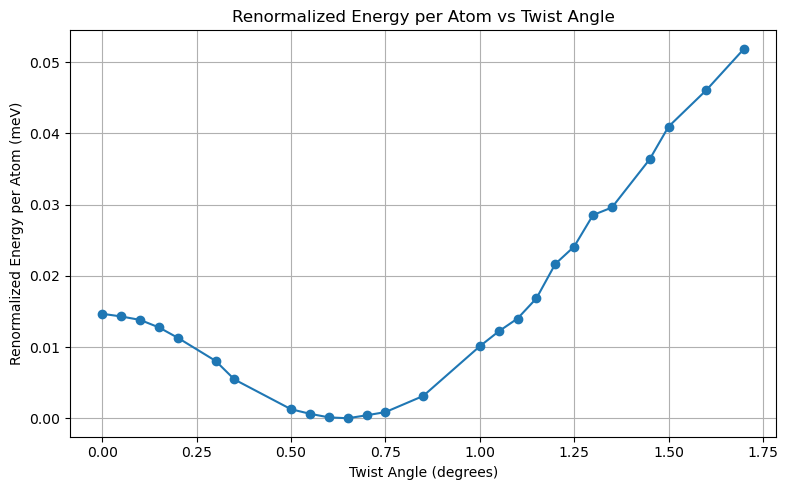

0    -7387.040668
5    -7387.041041
1    -7387.041524
11   -7387.042581
2    -7387.044041
3    -7387.047278
13   -7387.049890
6    -7387.054069
15   -7387.054702
7    -7387.055206
16   -7387.055330
8    -7387.054917
17   -7387.054464
18   -7387.052202
20   -7387.045224
25   -7387.043139
21   -7387.041330
31   -7387.038497
22   -7387.033669
32   -7387.031227
23   -7387.026802
33   -7387.025745
34   -7387.018984
26   -7387.014397
27   -7387.009276
28   -7387.003469
Name: RenormalizedEnergy, dtype: float64


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# Set working directory
os.chdir("./")

# Input file
filename = 'angle_energy_atoms_FixBN.txt'

# Reference lattice constant (unstrained)
a_ref = 2.505759  # in Angstrom

# Load data
df = pd.read_csv(filename, delim_whitespace=True, comment='#', na_values=['NA'])

# Drop rows with missing data
df = df.dropna(subset=['FinalEnergy(eV)', 'NumAtoms', 'LatticeParam(Å)'])

# Ensure numeric types
df['FinalEnergy(eV)'] = pd.to_numeric(df['FinalEnergy(eV)'])
df['NumAtoms'] = pd.to_numeric(df['NumAtoms'])
df['LatticeParam(Å)'] = pd.to_numeric(df['LatticeParam(Å)'])

# Energy per atom
df['EnergyPerAtom'] = df['FinalEnergy(eV)'] / df['NumAtoms'] #-7.06893843847837

# Renormalize by lattice constant ratio
df['RenormalizedEnergy'] = df['EnergyPerAtom'] * (1 + 0.045*(a_ref / df['LatticeParam(Å)'])) 

# Optional: add offset (e.g., to shift minimum to 0 or set reference)
# df['RenormalizedEnergy'] += 7.07020  # if needed

# Sort by angle
df = df.sort_values('Angle(deg)')

# Optional: vertical line at special angle (e.g., theta_A_deg)
# theta_A_deg = 0.6145
# plt.axvline(theta_A_deg, linestyle='--', color='gray')
# Plot
plt.figure(figsize=(8, 5))
#plt.axvline(theta_A_deg)
#plt.axvline(theta_Z_deg)
plt.plot(df['Angle(deg)'], (df['RenormalizedEnergy']- np.min(df['RenormalizedEnergy'])) * 1000, marker='o')
#plt.plot(df['Angle(deg)'], (df['RenormalizedEnergy']) * 1000, marker='o')
plt.xlabel('Twist Angle (degrees)')
plt.ylabel('Renormalized Energy per Atom (meV)')
plt.title('Renormalized Energy per Atom vs Twist Angle')
plt.grid(True)
plt.tight_layout()
plt.show()

print(df['RenormalizedEnergy'] * 1000)

f = open("Ene_p_FixBN_renormed.dat","w")
for ang,ene in zip(df['Angle(deg)'],df['RenormalizedEnergy']):
    f.write(str(ang)+" "+str(ene)+"\n")

f.close()

In [27]:
df

,Angle(deg),FinalEnergy(eV),NumAtoms,LatticeParam(Å),RigidEnergy(eV),CellInfoAngle(deg),EnergyPerAtom,RenormalizedEnergy
0,0.00,-8.399313e+04,11882.0,2.505759,-8.398897e+04,0.000000,-7.068938,-7.387041
5,0.05,-1.589677e+06,224882.0,2.505760,-1.589598e+06,0.065323,-7.068939,-7.387041
1,0.10,-2.331789e+06,329864.0,2.505759,-2.331673e+06,0.097491,-7.068939,-7.387042
11,0.15,-2.226193e+06,314926.0,2.505759,-2.226082e+06,0.143719,-7.068940,-7.387043
2,0.20,-1.054926e+06,149234.0,2.505759,-1.054874e+06,0.196871,-7.068942,-7.387044
3,0.30,-2.185463e+06,309164.0,2.505757,-2.185353e+06,0.290227,-7.068945,-7.387047
13,0.35,-2.326489e+06,329114.0,2.505757,-2.326371e+06,0.363111,-7.068947,-7.387050
6,0.50,-6.126095e+05,86662.0,2.505759,-6.125780e+05,0.508530,-7.068951,-7.387054
15,0.55,-2.050519e+06,290074.0,2.505759,-2.050414e+06,0.546119,-7.068952,-7.387055
7,0.60,-8.306867e+05,117512.0,2.505759,-8.306440e+05,0.589573,-7.068952,-7.387055


C:\Users\AN\AppData\Local\Temp\ipykernel_14440\2561143947.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, comment='#', na_values=['NA'])


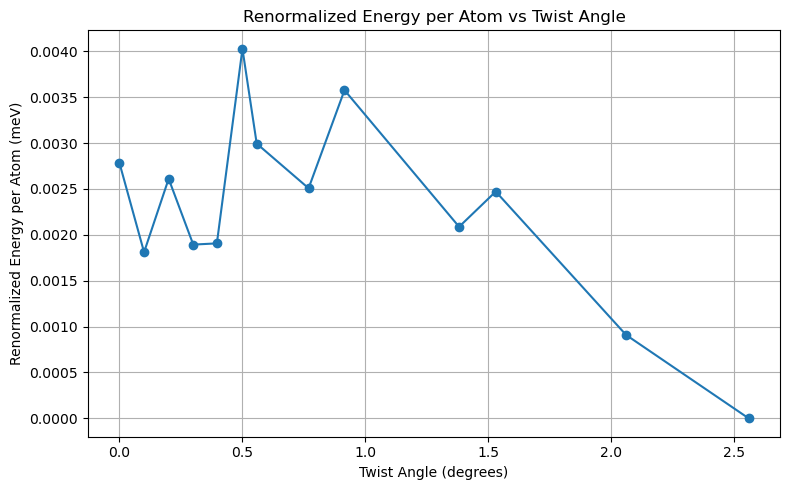

0    -7386.675247
1    -7386.676219
2    -7386.675418
3    -7386.676136
4    -7386.676123
5    -7386.674001
6    -7386.675035
7    -7386.675522
8    -7386.674452
9    -7386.675942
10   -7386.675558
11   -7386.677121
12   -7386.678029
Name: RenormalizedEnergy, dtype: float64


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# Set working directory
os.chdir("./")

# Input file
filename = 'InterEne2_FixBN.dat'

# Reference lattice constant (unstrained)
a_ref = 2.505759  # in Angstrom

# Load data
df = pd.read_csv(filename, delim_whitespace=True, comment='#', na_values=['NA'])

# Drop rows with missing data
df = df.dropna(subset=['FinalEnergy(eV)', 'NumAtoms', 'LatticeParam(Å)'])

# Ensure numeric types
df['FinalEnergy(eV)'] = pd.to_numeric(df['FinalEnergy(eV)'])
df['NumAtoms'] = pd.to_numeric(df['NumAtoms'])
df['LatticeParam(Å)'] = pd.to_numeric(df['LatticeParam(Å)'])

# Energy per atom
df['EnergyPerAtom'] = df['FinalEnergy(eV)'] / df['NumAtoms'] #-7.06893843847837

# Renormalize by lattice constant ratio
df['RenormalizedEnergy'] = df['EnergyPerAtom'] * (1 + 0.045*(a_ref / df['LatticeParam(Å)'])) 

# Optional: add offset (e.g., to shift minimum to 0 or set reference)
# df['RenormalizedEnergy'] += 7.07020  # if needed

# Sort by angle
df = df.sort_values('Angle(deg)')

# Optional: vertical line at special angle (e.g., theta_A_deg)
# theta_A_deg = 0.6145
# plt.axvline(theta_A_deg, linestyle='--', color='gray')

# Plot
plt.figure(figsize=(8, 5))
#plt.axvline(theta_A_deg)
#plt.axvline(theta_Z_deg)
plt.plot(df['Angle(deg)'], (df['RenormalizedEnergy']- np.min(df['RenormalizedEnergy'])) * 1000, marker='o')
#plt.plot(df['Angle(deg)'], (df['RenormalizedEnergy']) * 1000, marker='o')
plt.xlabel('Twist Angle (degrees)')
plt.ylabel('Renormalized Energy per Atom (meV)')
plt.title('Renormalized Energy per Atom vs Twist Angle')
plt.grid(True)
plt.tight_layout()
plt.show()

print(df['RenormalizedEnergy'] * 1000)

In [37]:
df

,Angle(deg),FinalEnergy(eV),NumAtoms,LatticeParam(Å),RigidEnergy(eV),EnergyPerAtom,RenormalizedEnergy
0,0.000,-83988.971567,11882,2.505759,NaN,-7.068589,-7.386675
1,0.100,-84751.787215,11990,2.505345,NaN,-7.068539,-7.386676
2,0.200,-80991.825002,11458,2.505711,NaN,-7.068583,-7.386675
3,0.300,-79676.287383,11272,2.505135,NaN,-7.068514,-7.386676
4,0.396,-74502.515562,10540,2.505432,NaN,-7.068550,-7.386676
5,0.500,-68212.159479,9650,2.506006,NaN,-7.068618,-7.386674
6,0.558,-65412.784763,9254,2.505818,NaN,-7.068596,-7.386675
7,0.769,-54725.002997,7742,2.505745,NaN,-7.068587,-7.386676
8,0.915,-47557.630813,6728,2.505968,NaN,-7.068613,-7.386674
9,1.381,-92485.408052,13084,2.505749,NaN,-7.068588,-7.386676


C:\Users\AN\AppData\Local\Temp\ipykernel_9608\314592320.py:16: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, comment='#', na_values=['NA'])


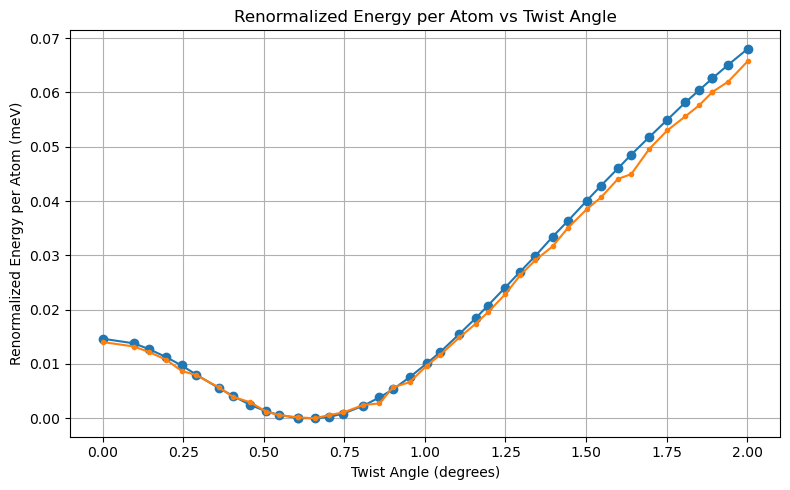

0    -7379.971730
1    -7379.972585
2    -7379.973641
3    -7379.975099
4    -7379.976658
5    -7379.978328
6    -7379.980786
7    -7379.982264
8    -7379.983912
9    -7379.985117
10   -7379.985750
11   -7379.986348
12   -7379.986348
13   -7379.986377
14   -7379.986148
15   -7379.985507
16   -7379.984068
17   -7379.982542
18   -7379.981064
19   -7379.978818
21   -7379.976282
22   -7379.974198
23   -7379.970845
24   -7379.967941
25   -7379.965646
26   -7379.962303
27   -7379.959391
28   -7379.956460
29   -7379.952971
30   -7379.950061
31   -7379.946294
32   -7379.943548
33   -7379.940368
34   -7379.937836
35   -7379.934566
36   -7379.931413
37   -7379.928225
38   -7379.925999
39   -7379.923769
40   -7379.923769
41   -7379.921285
43   -7379.918348
Name: RenormalizedEnergy, dtype: float64


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# Set working directory
os.chdir("./")

# Input file
filename = 'angle_energy_atoms_FixBN (2).txt'

# Reference lattice constant (unstrained)
a_ref = 2.505759  # in Angstrom

# Load data
df = pd.read_csv(filename, delim_whitespace=True, comment='#', na_values=['NA'])

# Drop rows with missing data
df = df.dropna(subset=['FinalEnergy(eV)', 'NumAtoms', 'LatticeParam(Å)'])

# Ensure numeric types
df['FinalEnergy(eV)'] = pd.to_numeric(df['FinalEnergy(eV)'])
df['NumAtoms'] = pd.to_numeric(df['NumAtoms'])
df['LatticeParam(Å)'] = pd.to_numeric(df['LatticeParam(Å)'])

# Energy per atom
df['EnergyPerAtom'] = df['FinalEnergy(eV)'] / df['NumAtoms'] #-7.06893843847837

# Renormalize by lattice constant ratio
df['RenormalizedEnergy'] = df['EnergyPerAtom'] * (1 + 0.044*(a_ref / df['LatticeParam(Å)'])) 
df['RenormalizedEnergy'] = df['EnergyPerAtom'] * (1 + 0.044*(a_ref / df['LatticeParam(Å)'])) 

# Optional: add offset (e.g., to shift minimum to 0 or set reference)
# df['RenormalizedEnergy'] += 7.07020  # if needed

# Sort by angle
df = df.sort_values('Angle(deg)')

# Optional: vertical line at special angle (e.g., theta_A_deg)
# theta_A_deg = 0.6145
# plt.axvline(theta_A_deg, linestyle='--', color='gray')
# Plot
plt.figure(figsize=(8, 5))
#plt.axvline(theta_A_deg)
#plt.axvline(theta_Z_deg)
plt.plot(df['Angle(deg)'], (df['RenormalizedEnergy']- np.min(df['RenormalizedEnergy'])) * 1000, marker='o')
plt.plot(df['Angle(deg)'], (df['EnergyPerAtom']- np.min(df['EnergyPerAtom'])) * 1000, marker='.')
#plt.plot(df['Angle(deg)'], (df['RenormalizedEnergy']) * 1000, marker='o')
plt.xlabel('Twist Angle (degrees)')
plt.ylabel('Renormalized Energy per Atom (meV)')
plt.title('Renormalized Energy per Atom vs Twist Angle')
plt.grid(True)
plt.tight_layout()
plt.show()

print(df['RenormalizedEnergy'] * 1000)

f = open("Ene_p_FixBN_renormed.dat","w")
for ang,ene in zip(df['Angle(deg)'],df['RenormalizedEnergy']):
    f.write(str(ang)+" "+str(ene)+"\n")

f.close()

,Angle(deg),FinalEnergy(eV),NumAtoms,LatticeParam(Å),RigidEnergy(eV),CellInfoAngle(deg),EnergyPerAtom,RenormalizedEnergy
0,0.000000,-8.399313e+04,11882.0,2.505759,-8.398897e+04,0.00,-7.068938,-7.379972
5,0.065323,-1.589677e+06,224882.0,2.505760,-1.589598e+06,0.05,-7.068939,-7.379972
1,0.097491,-2.331789e+06,329864.0,2.505759,-2.331673e+06,0.10,-7.068939,-7.379973
11,0.143719,-2.226193e+06,314926.0,2.505759,-2.226082e+06,0.15,-7.068940,-7.379974
2,0.196871,-1.054926e+06,149234.0,2.505759,-1.054874e+06,0.20,-7.068942,-7.379975
3,0.290227,-2.185463e+06,309164.0,2.505757,-2.185353e+06,0.30,-7.068945,-7.379978
13,0.363111,-2.326489e+06,329114.0,2.505757,-2.326371e+06,0.35,-7.068947,-7.379981
6,0.508530,-6.126095e+05,86662.0,2.505759,-6.125780e+05,0.50,-7.068951,-7.379985
15,0.546119,-2.050519e+06,290074.0,2.505759,-2.050414e+06,0.55,-7.068952,-7.379986
7,0.589573,-8.306867e+05,117512.0,2.505759,-8.306440e+05,0.60,-7.068952,-7.379986
